In [ ]:
!pip install scanpy squidpy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import

In [ ]:
import torch

if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("Using CPU")

Using CPU


In [ ]:
import os
import sys

os.chdir("/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Classification_Assesment")
cwd = os.getcwd()
print(cwd)
sys.path.append("../../")

/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Classification_Assesment


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from tqdm.auto import tqdm

## Classification Network

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report


# ============================================================
# PyTorch Dataset
# ============================================================

class AnnDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

"""
# ============================================================
# Two-layer Neural Network
# ============================================================

class TwoLayerNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)
"""

'\n# ============================================================\n# Two-layer Neural Network\n# ============================================================\n\nclass TwoLayerNN(nn.Module):\n    def __init__(self, input_dim, hidden_dim, num_classes):\n        super().__init__()\n\n        self.network = nn.Sequential(\n            nn.Linear(input_dim, hidden_dim),\n            nn.ReLU(),\n            nn.Linear(hidden_dim, num_classes)\n        )\n\n    def forward(self, x):\n        return self.network(x)\n'

In [ ]:
# ============================================================
# Two-layer Neural Network
# ============================================================

class TwoLayerNN(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_classes,
        use_dropout=False,
        dropout=0.5
    ):
        super().__init__()

        layers = [
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        ]

        # Add dropout only if enabled
        if use_dropout:
            layers.append(nn.Dropout(p=dropout))

        layers.append(
            nn.Linear(hidden_dim, num_classes)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [ ]:
ACC = {}

## Gene Only

In [ ]:
ad = sc.read_h5ad("../../../Data/Breast_Cancer/ann_data.h5ad")

In [ ]:
admask = ad.obs["annotation"].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
adata = ad[admask].copy()

In [ ]:
# Get x coordinates from obsm["spatial"]
x_coords = adata.obsm["spatial"][:, 0]
y_coords = adata.obsm["spatial"][:, 1]

# Set target annotation
target_annotation1 = 'DCIS_1'
x_threshold1 = 6450

target_annotation2 = 'DCIS_2'
y_threshold2 = 2350

target_annotation3 = 'Invasive'
y_threshold3 = 2000

# Build boolean mask
mask1 = (
    (adata.obs["annotation"] == target_annotation1) &
    (x_coords > x_threshold1)
)

mask2 = (
    (adata.obs["annotation"] == target_annotation2) &
    (y_coords < y_threshold2)
)

mask3 = (
    (adata.obs["annotation"] == target_annotation3) &
    (y_coords > y_threshold3)
)

mask = mask1 | mask2 | mask3

# Subset AnnData
adata_subset = adata[mask].copy()

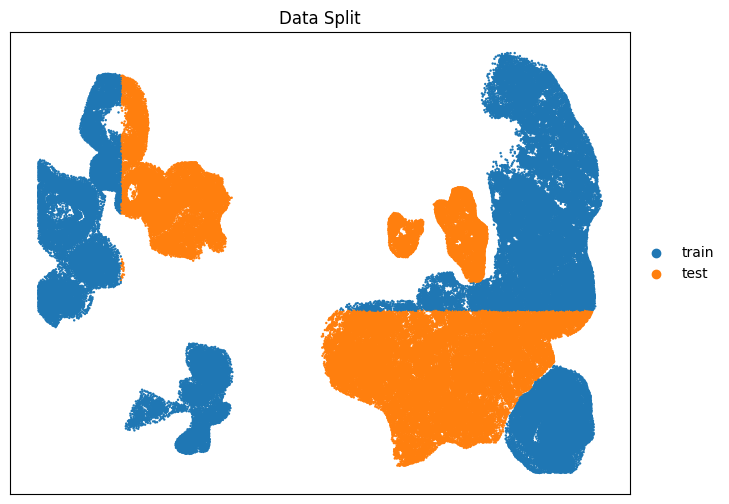

In [ ]:
# Store mask
adata.obs["selected_mask"] = mask

adata.obs["selected_mask_label"] = pd.Categorical(
    adata.obs["selected_mask"].map({
        True: "train",
        False: "test"
    }),
    categories=["train", "test"]
)

fig, ax = plt.subplots(figsize=(8, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="selected_mask_label",
    size=12,
    title="Data Split",
    ax=ax,
    show=False
)

# Flip x-axis
ax.invert_xaxis()

# Remove axis labels
ax.set_xlabel("")
ax.set_ylabel("")

plt.show()


In [ ]:
# ============================================================
# Prepare data from AnnData
# ============================================================

# Features
X = adata.X

# Convert sparse matrix to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

X = X.astype(np.float32)

# Labels
y = adata.obs["annotation"].values

# Boolean mask
train_mask = mask
test_mask = ~mask

# Encode labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

In [ ]:
X_train.shape

(48548, 313)

In [ ]:
X_test.shape

(38452, 313)

In [ ]:
# ============================================================
# PyTorch Dataset
# ============================================================

train_dataset = AnnDataset(X_train, y_train)
test_dataset = AnnDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=40000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=40000, shuffle=False)

# ============================================================
# Model
# ============================================================

input_dim = X_train.shape[1]
hidden_dim = 128
num_classes = len(np.unique(y_encoded))

model = TwoLayerNN(input_dim, hidden_dim, num_classes)

# ============================================================
# Training setup
# ============================================================

criterion = nn.CrossEntropyLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

TwoLayerNN(
  (network): Sequential(
    (0): Linear(in_features=313, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [ ]:
# ============================================================
# Training loop
# ============================================================

# 1. 500 --> 0.1 (0.2) | 2. 500 --> 0.001 (0.17) | 3. 500 --> 0.0001 (0.16)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 28.9321
Epoch [101/500] Loss: 0.2556
Epoch [201/500] Loss: 0.2420
Epoch [301/500] Loss: 0.2371
Epoch [401/500] Loss: 0.2072


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.2119
Epoch [101/500] Loss: 0.1950
Epoch [201/500] Loss: 0.1865
Epoch [301/500] Loss: 0.1885
Epoch [401/500] Loss: 0.1879


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.1864
Epoch [101/500] Loss: 0.1877
Epoch [201/500] Loss: 0.1833
Epoch [301/500] Loss: 0.1842
Epoch [401/500] Loss: 0.1860


In [ ]:
# ============================================================
# Evaluation on test data
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)


Test Accuracy: 0.8418

Classification Report:
              precision    recall  f1-score   support

      DCIS_1       0.87      0.83      0.85      9674
      DCIS_2       0.45      0.42      0.43      4821
    Invasive       0.90      0.93      0.92     23957

    accuracy                           0.84     38452
   macro avg       0.74      0.73      0.73     38452
weighted avg       0.84      0.84      0.84     38452



In [ ]:
ACC['gene'] = 0.84

## Morpho Only (CNN)

## Morpho Only (UNI)

In [ ]:
ad = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/UNI_adata.h5ad")

In [ ]:
admask = ad.obs["annotation"].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
adata = ad[admask].copy()

In [ ]:
# Get x coordinates from obsm["spatial"]
x_coords = adata.obsm["spatial"][:, 0]
y_coords = adata.obsm["spatial"][:, 1]

# Set target annotation
target_annotation1 = 'DCIS_1'
x_threshold1 = 6450

target_annotation2 = 'DCIS_2'
y_threshold2 = 2350

target_annotation3 = 'Invasive'
y_threshold3 = 2000

# Build boolean mask
mask1 = (
    (adata.obs["annotation"] == target_annotation1) &
    (x_coords > x_threshold1)
)

mask2 = (
    (adata.obs["annotation"] == target_annotation2) &
    (y_coords < y_threshold2)
)

mask3 = (
    (adata.obs["annotation"] == target_annotation3) &
    (y_coords > y_threshold3)
)

mask = mask1 | mask2 | mask3

# Subset AnnData
adata_subset = adata[mask].copy()

In [ ]:
# ============================================================
# Prepare data from AnnData
# ============================================================

# Features
X = adata.obsm['p_Morpho_Embedding']

# Convert sparse matrix to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

X = X.astype(np.float32)

# Labels
y = adata.obs["annotation"].values

# Boolean mask
train_mask = mask
test_mask = ~mask

# Encode labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

In [ ]:
# ============================================================
# PyTorch Dataset
# ============================================================

train_dataset = AnnDataset(X_train, y_train)
test_dataset = AnnDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=40000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=40000, shuffle=False)

# ============================================================
# Model
# ============================================================

input_dim = X_train.shape[1]
hidden_dim = 128
num_classes = len(np.unique(y_encoded))

model = TwoLayerNN(
    input_dim,
    hidden_dim,
    num_classes,
    use_dropout=True,
    dropout=0.3
    )

# ============================================================
# Training setup
# ============================================================

criterion = nn.CrossEntropyLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

TwoLayerNN(
  (network): Sequential(
    (0): Linear(in_features=500, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [ ]:
# ============================================================
# Training loop
# ============================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 10 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 20 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

In [ ]:
# ============================================================
# Evaluation on test data
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)


Test Accuracy: 0.8541

Classification Report:
              precision    recall  f1-score   support

      DCIS_1       0.83      0.87      0.85      9674
      DCIS_2       0.50      0.41      0.45      4821
    Invasive       0.92      0.93      0.93     23957

    accuracy                           0.85     38452
   macro avg       0.75      0.74      0.74     38452
weighted avg       0.85      0.85      0.85     38452



In [ ]:
ACC['UNI'] = 0.85

## Steamboat

In [ ]:
sys.path.append("../../SteamBoat")

In [ ]:
import importlib
import steamboat as sf
import steamboat.model as sm
import steamboat.tools
import steamboat.model

In [ ]:
ad = sc.read_h5ad("../../../Data/Breast_Cancer/ann_data.h5ad")

In [ ]:
ads = []
for i in ad.obs['region'].unique():
    ads.append(ad[ad.obs['region'] == i])
    ads[-1].obs['global'] = 0  #Only support one unique value for regional observation.

ads = sf.prep_adatas(ads, norm=True, log1p=True)
dataset = sf.make_dataset(ads, sparse_graph=True, regional_obs=['global'])

/tmp/ipykernel_6166/1707932860.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ads[-1].obs['global'] = 0  #Only support one unique value for regional observation.


  0%|          | 0/1 [00:00<?, ?it/s]

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.
Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
sf.set_random_seed(0)
model = sm.Steamboat(ads[0].var_names.tolist(), n_heads=64, n_scales=3)
model = model.to(device)

model.load_state_dict(
    torch.load(
        '../../SteamBoat/examples/saved_models/Breast_Cancer_64_0.8.pth',
        map_location=torch.device(device),
        weights_only=True
        ), strict=False
    )

sf.tools.calc_obs(ads, dataset, model)

100%|██████████| 1/1 [00:19<00:00, 19.46s/it]


In [ ]:
ad.obsm['attn'] = ads[0].obsm['attn']

In [ ]:
admask = ad.obs["annotation"].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
adata = ad[admask].copy()

In [ ]:
# Get x coordinates from obsm["spatial"]
x_coords = adata.obsm["spatial"][:, 0]
y_coords = adata.obsm["spatial"][:, 1]

# Set target annotation
target_annotation1 = 'DCIS_1'
x_threshold1 = 6450

target_annotation2 = 'DCIS_2'
y_threshold2 = 2350

target_annotation3 = 'Invasive'
y_threshold3 = 2000

# Build boolean mask
mask1 = (
    (adata.obs["annotation"] == target_annotation1) &
    (x_coords > x_threshold1)
)

mask2 = (
    (adata.obs["annotation"] == target_annotation2) &
    (y_coords < y_threshold2)
)

mask3 = (
    (adata.obs["annotation"] == target_annotation3) &
    (y_coords > y_threshold3)
)

mask = mask1 | mask2 | mask3

# Subset AnnData
adata_subset = adata[mask].copy()

In [ ]:
# ============================================================
# Prepare data from AnnData
# ============================================================

# Features
X = adata.obsm['attn']

# Convert sparse matrix to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

X = X.astype(np.float32)

# Labels
y = adata.obs["annotation"].values

# Boolean mask
train_mask = mask
test_mask = ~mask

# Encode labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

In [ ]:
# ============================================================
# PyTorch Dataset
# ============================================================

train_dataset = AnnDataset(X_train, y_train)
test_dataset = AnnDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=40000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=40000, shuffle=False)

# ============================================================
# Model
# ============================================================

input_dim = X_train.shape[1]
hidden_dim = 128
num_classes = len(np.unique(y_encoded))

model = TwoLayerNN(input_dim, hidden_dim, num_classes)

# ============================================================
# Training setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

TwoLayerNN(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [ ]:
# ============================================================
# Training loop
# ============================================================

# 1. 500 --> 0.1 (0.09) | 2. 500 --> 0.001 (0.03) | 3. 500 --> 0.0001 (0.03)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 1.1449
Epoch [101/500] Loss: 0.1258
Epoch [201/500] Loss: 0.1030
Epoch [301/500] Loss: 0.0943
Epoch [401/500] Loss: 0.0921


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.0875
Epoch [101/500] Loss: 0.0775
Epoch [201/500] Loss: 0.0761
Epoch [301/500] Loss: 0.0731
Epoch [401/500] Loss: 0.0750


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.0710
Epoch [101/500] Loss: 0.0687
Epoch [201/500] Loss: 0.0726
Epoch [301/500] Loss: 0.0698
Epoch [401/500] Loss: 0.0718


In [ ]:
# ============================================================
# Evaluation on test data
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)


Test Accuracy: 0.8783

Classification Report:
              precision    recall  f1-score   support

      DCIS_1       0.94      0.89      0.91      9674
      DCIS_2       0.56      0.39      0.46      4821
    Invasive       0.90      0.97      0.93     23957

    accuracy                           0.88     38452
   macro avg       0.80      0.75      0.77     38452
weighted avg       0.87      0.88      0.87     38452



In [ ]:
ACC['steamboat'] = 0.88

## Hadamard Full

In [ ]:
import HadmardAttention as HA

In [ ]:
import importlib
import HadmardAttention.tools
import HadmardAttention.model

In [ ]:
ad = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/UNI_adata.h5ad")

In [ ]:
ad = HA.prep_adatas(ad, norm=True, log1p=True)
dataset = HA.make_dataset(ad, sparse_graph=True)

/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Classification_Assesment/../../HadmardAttention/dataset.py:37: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.


In [ ]:
model_type = 0

HA.set_random_seed(42)
model = HA.model.Steamboat(features=len(ad.var_names.tolist()), morpho_features=ad.obsm['p_Morpho_Embedding'].shape[1], n_heads=32, model_type=model_type, n_scales=2)
model = model.to(device)

model.load_state_dict(torch.load(f'../Hadmard_Attention/saved_models/breast_cancer_32_UNI_{model_type}.pth',weights_only=True, map_location=torch.device(device)))


<All keys matched successfully>

In [ ]:
loader = DataLoader(dataset, batch_size=1, shuffle=False)

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    res, details = model(adj_list, x, m, x, m, get_details=True)

model_type:  0


In [ ]:
ad.obsm['attnhf'] = details['attn'].cpu().numpy()

In [ ]:
admask = ad.obs["annotation"].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
adata = ad[admask].copy()

In [ ]:
# Get x coordinates from obsm["spatial"]
x_coords = adata.obsm["spatial"][:, 0]
y_coords = adata.obsm["spatial"][:, 1]

# Set target annotation
target_annotation1 = 'DCIS_1'
x_threshold1 = 6450

target_annotation2 = 'DCIS_2'
y_threshold2 = 2350

target_annotation3 = 'Invasive'
y_threshold3 = 2000

# Build boolean mask
mask1 = (
    (adata.obs["annotation"] == target_annotation1) &
    (x_coords > x_threshold1)
)

mask2 = (
    (adata.obs["annotation"] == target_annotation2) &
    (y_coords < y_threshold2)
)

mask3 = (
    (adata.obs["annotation"] == target_annotation3) &
    (y_coords > y_threshold3)
)

mask = mask1 | mask2 | mask3

# Subset AnnData
adata_subset = adata[mask].copy()

In [ ]:
# ============================================================
# Prepare data from AnnData
# ============================================================

# Features
X = adata.obsm['attnhf']

# Convert sparse matrix to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

X = X.astype(np.float32)

# Labels
y = adata.obs["annotation"].values

# Boolean mask
train_mask = mask
test_mask = ~mask

# Encode labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

In [ ]:
# ============================================================
# PyTorch Dataset
# ============================================================

train_dataset = AnnDataset(X_train, y_train)
test_dataset = AnnDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=40000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=40000, shuffle=False)

# ============================================================
# Model
# ============================================================

input_dim = X_train.shape[1]
hidden_dim = 128
num_classes = len(np.unique(y_encoded))

model = TwoLayerNN(input_dim, hidden_dim, num_classes)

# ============================================================
# Training setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

TwoLayerNN(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [ ]:
# ============================================================
# Training loop
# ============================================================

# 1. 500 --> 0.1 (0.19) | 2. 500 --> 0.001 (0.19) | 3. 500 --> 0.0001 (0.18)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 1.1029
Epoch [101/500] Loss: 0.2364
Epoch [201/500] Loss: 0.2165
Epoch [301/500] Loss: 0.2082
Epoch [401/500] Loss: 0.2000


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.1945
Epoch [101/500] Loss: 0.1873
Epoch [201/500] Loss: 0.1798
Epoch [301/500] Loss: 0.1846
Epoch [401/500] Loss: 0.1876


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.1831
Epoch [101/500] Loss: 0.1826
Epoch [201/500] Loss: 0.1802
Epoch [301/500] Loss: 0.1833
Epoch [401/500] Loss: 0.1787


In [ ]:
# ============================================================
# Evaluation on test data
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)


Test Accuracy: 0.8465

Classification Report:
              precision    recall  f1-score   support

      DCIS_1       0.89      0.84      0.87      9674
      DCIS_2       0.45      0.34      0.39      4821
    Invasive       0.89      0.95      0.92     23957

    accuracy                           0.85     38452
   macro avg       0.74      0.71      0.72     38452
weighted avg       0.83      0.85      0.84     38452



In [ ]:
ACC['Hadamard Full'] = 0.85

## Hadamard Cross

In [ ]:
import HadmardAttention as HA

In [ ]:
import importlib
import HadmardAttention.tools
import HadmardAttention.model

In [ ]:
ad = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/UNI_adata.h5ad")

In [ ]:
ad = HA.prep_adatas(ad, norm=True, log1p=True)
dataset = HA.make_dataset(ad, sparse_graph=True)

/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Classification_Assesment/../../HadmardAttention/dataset.py:37: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.


In [ ]:
model_type = 5

HA.set_random_seed(42)
model = HA.model.Steamboat(features=len(ad.var_names.tolist()), morpho_features=ad.obsm['p_Morpho_Embedding'].shape[1], n_heads=32, model_type=model_type, n_scales=2)
model = model.to(device)


if device == 'cpu':
  model.load_state_dict(torch.load(f'../Hadmard_Attention/saved_models/breast_cancer_32_UNI_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load(f'../Hadmard_Attention/saved_models/breast_cancer_32_UNI_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))

In [ ]:
loader = DataLoader(dataset, batch_size=1, shuffle=False)

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    res, details = model(adj_list, x, m, x, m, get_details=True)

model_type:  5


In [ ]:
ad.obsm['attnhs'] = details['attn'].cpu().numpy()

In [ ]:
admask = ad.obs["annotation"].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
adata = ad[admask].copy()

In [ ]:
# Get x coordinates from obsm["spatial"]
x_coords = adata.obsm["spatial"][:, 0]
y_coords = adata.obsm["spatial"][:, 1]

# Set target annotation
target_annotation1 = 'DCIS_1'
x_threshold1 = 6450

target_annotation2 = 'DCIS_2'
y_threshold2 = 2350

target_annotation3 = 'Invasive'
y_threshold3 = 2000

# Build boolean mask
mask1 = (
    (adata.obs["annotation"] == target_annotation1) &
    (x_coords > x_threshold1)
)

mask2 = (
    (adata.obs["annotation"] == target_annotation2) &
    (y_coords < y_threshold2)
)

mask3 = (
    (adata.obs["annotation"] == target_annotation3) &
    (y_coords > y_threshold3)
)

mask = mask1 | mask2 | mask3

# Subset AnnData
adata_subset = adata[mask].copy()

In [ ]:
# ============================================================
# Prepare data from AnnData
# ============================================================

# Features
X = adata.obsm['attnhs']

# Convert sparse matrix to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

X = X.astype(np.float32)

# Labels
y = adata.obs["annotation"].values

# Boolean mask
train_mask = mask
test_mask = ~mask

# Encode labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

In [ ]:
# ============================================================
# PyTorch Dataset
# ============================================================

train_dataset = AnnDataset(X_train, y_train)
test_dataset = AnnDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=40000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=40000, shuffle=False)

# ============================================================
# Model
# ============================================================

input_dim = X_train.shape[1]
hidden_dim = 128
num_classes = len(np.unique(y_encoded))

model = TwoLayerNN(input_dim, hidden_dim, num_classes)

# ============================================================
# Training setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

TwoLayerNN(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [ ]:
# ============================================================
# Training loop
# ============================================================

# 1. 500 --> 0.1 (0.13) | 2. 500 --> 0.001 (0.10) | 3. 500 --> 0.0001 (0.10)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 1.0957
Epoch [101/500] Loss: 0.2123
Epoch [201/500] Loss: 0.1899
Epoch [301/500] Loss: 0.1775
Epoch [401/500] Loss: 0.1743


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.1773
Epoch [101/500] Loss: 0.1638
Epoch [201/500] Loss: 0.1622
Epoch [301/500] Loss: 0.1594
Epoch [401/500] Loss: 0.1665


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.1638
Epoch [101/500] Loss: 0.1634
Epoch [201/500] Loss: 0.1586
Epoch [301/500] Loss: 0.1642
Epoch [401/500] Loss: 0.1640


In [ ]:
# ============================================================
# Evaluation on test data
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)


Test Accuracy: 0.8546

Classification Report:
              precision    recall  f1-score   support

      DCIS_1       0.88      0.85      0.87      9674
      DCIS_2       0.47      0.40      0.43      4821
    Invasive       0.91      0.95      0.93     23957

    accuracy                           0.85     38452
   macro avg       0.75      0.73      0.74     38452
weighted avg       0.85      0.85      0.85     38452



In [ ]:
ACC['Hadamard Cross'] = 0.85

## GNN & Self Attention

In [ ]:
!pip install torch_geometric

In [ ]:
import torch.nn.functional as F
import SelfAttention as SA
import importlib

In [ ]:
ad = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/UNI_adata.h5ad")

In [ ]:
ad = SA.prep_adata(ad, norm=True, log1p=True)
data = SA.build_graph(ad, k=8, morph_key='p_Morpho_Embedding')

/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Classification_Assesment/../../SelfAttention/dataset.py:13: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


In [ ]:
SA.set_random_seed(42)
model = SA.SpatialTransformerAE(
    in_dim=data.x.shape[1],
    gene_dim=data.gene_dim,
    hidden_dim=96,
    latent_dim=64,
    heads=4
)

model.load_state_dict(torch.load(f'../SelfAttention/saved_models/Breast_Cancer_64_UNI_0.8.pth',weights_only=True, map_location=torch.device(device)))

<All keys matched successfully>

In [ ]:
gene_dim = data.gene_dim
with torch.no_grad():
  x = data.x.clone()
  out, z = model(x, data.edge_index, data.edge_attr, details=True)
  print('rec loss', F.mse_loss(out, x[:, :gene_dim]))

rec loss tensor(0.1496)


In [ ]:
ad.obsm['z'] = z.cpu().numpy()

In [ ]:
admask = ad.obs["annotation"].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
adata = ad[admask].copy()

In [ ]:
# Get x coordinates from obsm["spatial"]
x_coords = adata.obsm["spatial"][:, 0]
y_coords = adata.obsm["spatial"][:, 1]

# Set target annotation
target_annotation1 = 'DCIS_1'
x_threshold1 = 6450

target_annotation2 = 'DCIS_2'
y_threshold2 = 2350

target_annotation3 = 'Invasive'
y_threshold3 = 2000

# Build boolean mask
mask1 = (
    (adata.obs["annotation"] == target_annotation1) &
    (x_coords > x_threshold1)
)

mask2 = (
    (adata.obs["annotation"] == target_annotation2) &
    (y_coords < y_threshold2)
)

mask3 = (
    (adata.obs["annotation"] == target_annotation3) &
    (y_coords > y_threshold3)
)

mask = mask1 | mask2 | mask3

# Subset AnnData
adata_subset = adata[mask].copy()

In [ ]:
# ============================================================
# Prepare data from AnnData
# ============================================================

# Features
X = adata.obsm['z']

# Convert sparse matrix to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

X = X.astype(np.float32)

# Labels
y = adata.obs["annotation"].values

# Boolean mask
train_mask = mask
test_mask = ~mask

# Encode labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

In [ ]:
# ============================================================
# PyTorch Dataset
# ============================================================

train_dataset = AnnDataset(X_train, y_train)
test_dataset = AnnDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=40000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=40000, shuffle=False)

# ============================================================
# Model
# ============================================================

input_dim = X_train.shape[1]
hidden_dim = 128
num_classes = len(np.unique(y_encoded))

model = TwoLayerNN(input_dim, hidden_dim, num_classes)

# ============================================================
# Training setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

TwoLayerNN(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [ ]:
# ============================================================
# Training loop
# ============================================================

# 1. 500 --> 0.1 (0.06) | 2. 500 --> 0.001 (0.05) | 3. 500 --> 0.0001 (0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 500

for epoch in tqdm(range(num_epochs)):
    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if epoch % 100 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 11.3753
Epoch [101/500] Loss: 0.1405
Epoch [201/500] Loss: 0.1312
Epoch [301/500] Loss: 0.1291
Epoch [401/500] Loss: 0.1223


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.1269
Epoch [101/500] Loss: 0.1112
Epoch [201/500] Loss: 0.1129
Epoch [301/500] Loss: 0.1157
Epoch [401/500] Loss: 0.1102


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/500] Loss: 0.1109
Epoch [101/500] Loss: 0.1097
Epoch [201/500] Loss: 0.1104
Epoch [301/500] Loss: 0.1121
Epoch [401/500] Loss: 0.1129


In [ ]:
# ============================================================
# Evaluation on test data
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)


Test Accuracy: 0.8989

Classification Report:
              precision    recall  f1-score   support

      DCIS_1       0.95      0.88      0.91      9674
      DCIS_2       0.62      0.61      0.62      4821
    Invasive       0.93      0.97      0.95     23957

    accuracy                           0.90     38452
   macro avg       0.84      0.82      0.83     38452
weighted avg       0.90      0.90      0.90     38452



In [ ]:
ACC['GNN'] = 0.90

## Plots

In [ ]:
for a in ACC:
  print(a, ": ", ACC[a])

GNN :  0.9
Hadamard Cross :  0.85
Hadamard Full :  0.85
steamboat :  0.88
UNI :  0.65
gene :  0.84


In [ ]:
ACC = {}
ACC['GNN'] = 0.9
ACC['Hadamard Cross'] = 0.85
ACC['Hadamard Full'] = 0.85
ACC['steamboat'] = 0.88
ACC['UNI'] = 0.85
ACC['gene'] = 0.84

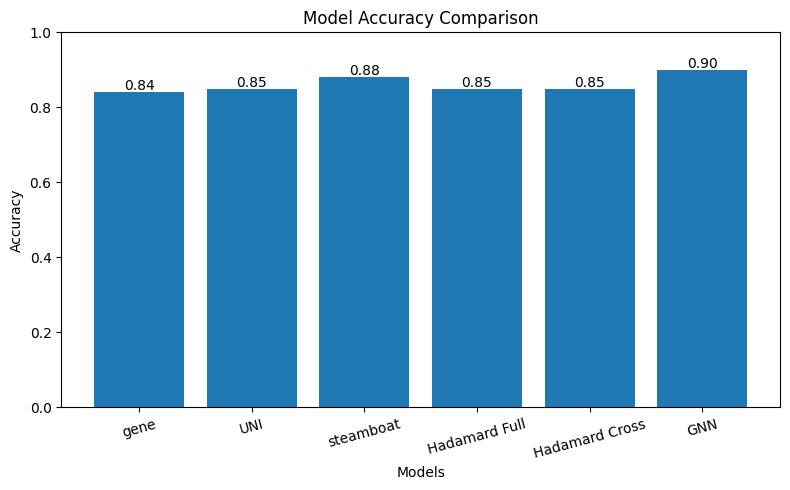

In [ ]:
# Extract keys and values
models = list(ACC.keys())[::-1]
accuracies = list(ACC.values())[::-1]

# Create bar plot
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

# Labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Optional: show accuracy values on top of bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.2f}", ha='center')

# Rotate model names if needed
plt.xticks(rotation=15)

# Show plot
plt.ylim(0, 1)   # since accuracy is between 0 and 1
plt.tight_layout()
plt.show()

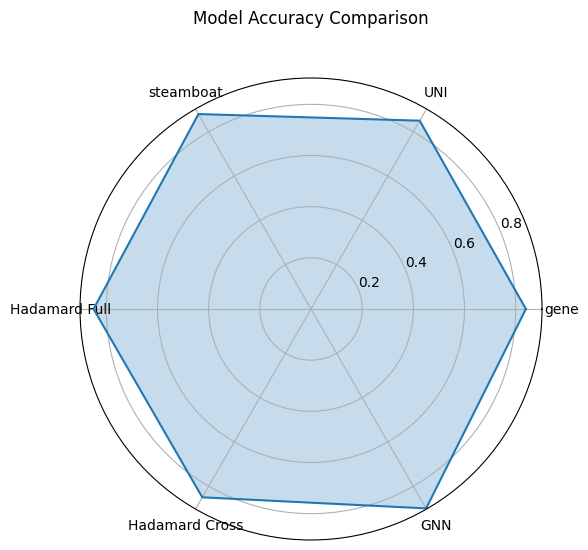

In [ ]:
labels = list(ACC.keys())[::-1]
values = list(ACC.values())[::-1]

# Close the circle
values += values[:1]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Model Accuracy Comparison", y=1.10)
plt.show()

In [2]:
MR = [0.2, 0.5, 0.8, 1.0]
Models = {}
Models['GNN'] = [0.0754, 0.0916, 0.1057, 0.1162]
Models['Hadamard Full'] = [0.0979, 0.1021, 0.0987, 0.1045]
Models['Hadamard Cross'] = [0.1008, 0.0985, 0.0996, 0.1185]
Models['SteaBoat'] = [0.0854, 0.1003, 0.1145, 0.2964]

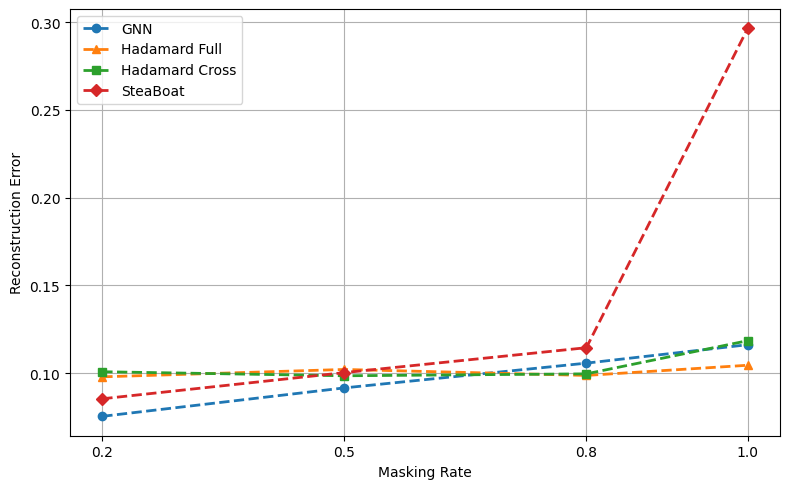

In [3]:
import matplotlib.pyplot as plt


marker_styles = {
    'GNN': 'o',              # circle
    'Hadamard Full': '^',    # triangle up
    'Hadamard Cross': 's',   # square
    'SteaBoat': 'D'          # diamond
}

plt.figure(figsize=(8, 5))

for model_name, accuracy in Models.items():
    plt.plot(
        MR,
        accuracy,
        marker=marker_styles.get(model_name, 'o'),
        linestyle='--',   # dashed line between MR points
        linewidth=2,
        label=model_name
    )

plt.xlabel('Masking Rate')
plt.ylabel('Reconstruction Error')

plt.xticks(MR)  # ensures only given MR values appear on x-axis
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
import seaborn as sns
import pandas as pd

In [10]:
df = pd.DataFrame(Models)

In [13]:
df['masking rate'] = MR

In [14]:
df

,GNN,Hadamard Full,Hadamard Cross,SteaBoat,masking rate
0,0.0754,0.0979,0.1008,0.0854,0.2
1,0.0916,0.1021,0.0985,0.1003,0.5
2,0.1057,0.0987,0.0996,0.1145,0.8
3,0.1162,0.1045,0.1185,0.2964,1.0


In [17]:
rows =[]
for model_name, accuracy in Models.items():
  for mr , acc in zip(MR, accuracy):
    rows.append([model_name, mr, acc])
df = pd.DataFrame(rows, columns=['model', 'masking rate', 'accuracy'])


In [18]:
df

,model,masking rate,accuracy
0,GNN,0.2,0.0754
1,GNN,0.5,0.0916
2,GNN,0.8,0.1057
3,GNN,1.0,0.1162
4,Hadamard Full,0.2,0.0979
5,Hadamard Full,0.5,0.1021
6,Hadamard Full,0.8,0.0987
7,Hadamard Full,1.0,0.1045
8,Hadamard Cross,0.2,0.1008
9,Hadamard Cross,0.5,0.0985


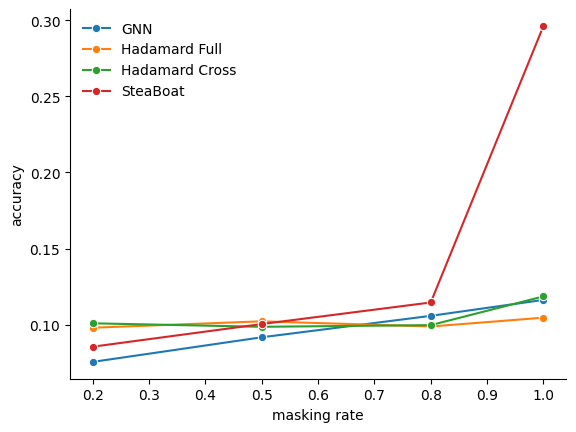

In [25]:
sns.lineplot(data=df, x='masking rate', y='accuracy', hue='model', marker='o')
sns.despine()
plt.legend(loc='upper left', frameon=False)
plt.show()

In [35]:
# multiple acc per model (eg different runs)
import numpy as np
rows =[]
for model_name, accuracy in Models.items():
  for mr , acc in zip(MR, accuracy):
    for i in range(5):
      rows.append([model_name, mr, acc*np.random.uniform(.8,1.3), model_name[:4]])
df = pd.DataFrame(rows, columns=['model', 'masking rate', 'accuracy', 'FM'])
df

,model,masking rate,accuracy,FM
0,GNN,0.2,0.086973,GNN
1,GNN,0.2,0.074833,GNN
2,GNN,0.2,0.097955,GNN
3,GNN,0.2,0.069189,GNN
4,GNN,0.2,0.089665,GNN
...,...,...,...,...
75,SteaBoat,1.0,0.280673,Stea
76,SteaBoat,1.0,0.270575,Stea
77,SteaBoat,1.0,0.354674,Stea
78,SteaBoat,1.0,0.284692,Stea


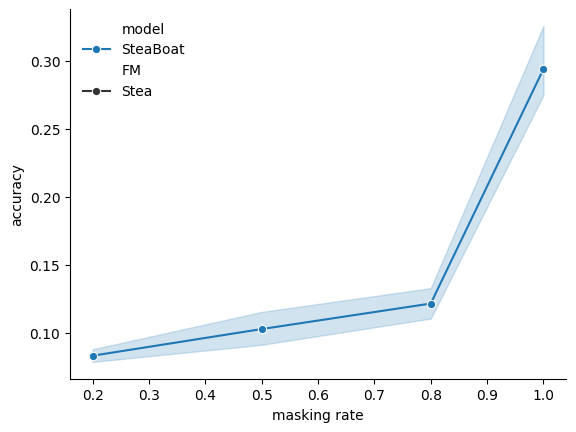

In [39]:
sns.lineplot(data=df[df['FM']=='Stea'], x='masking rate', y='accuracy', hue='model', style='FM',marker='o')
sns.despine()
plt.legend(loc='upper left', frameon=False)
plt.show()

In [37]:
df.to_latex()

'\\begin{tabular}{llrrl}\n\\toprule\n & model & masking rate & accuracy & FM \\\\\n\\midrule\n0 & GNN & 0.200000 & 0.086973 & GNN \\\\\n1 & GNN & 0.200000 & 0.074833 & GNN \\\\\n2 & GNN & 0.200000 & 0.097955 & GNN \\\\\n3 & GNN & 0.200000 & 0.069189 & GNN \\\\\n4 & GNN & 0.200000 & 0.089665 & GNN \\\\\n5 & GNN & 0.500000 & 0.098217 & GNN \\\\\n6 & GNN & 0.500000 & 0.089091 & GNN \\\\\n7 & GNN & 0.500000 & 0.095557 & GNN \\\\\n8 & GNN & 0.500000 & 0.084925 & GNN \\\\\n9 & GNN & 0.500000 & 0.110704 & GNN \\\\\n10 & GNN & 0.800000 & 0.112453 & GNN \\\\\n11 & GNN & 0.800000 & 0.124707 & GNN \\\\\n12 & GNN & 0.800000 & 0.105203 & GNN \\\\\n13 & GNN & 0.800000 & 0.123684 & GNN \\\\\n14 & GNN & 0.800000 & 0.113572 & GNN \\\\\n15 & GNN & 1.000000 & 0.109056 & GNN \\\\\n16 & GNN & 1.000000 & 0.102516 & GNN \\\\\n17 & GNN & 1.000000 & 0.104834 & GNN \\\\\n18 & GNN & 1.000000 & 0.107702 & GNN \\\\\n19 & GNN & 1.000000 & 0.134546 & GNN \\\\\n20 & Hadamard Full & 0.200000 & 0.110445 & Hada \\\\\n21

In [38]:
df.to_markdown()

'|    | model          |   masking rate |   accuracy | FM   |\n|---:|:---------------|---------------:|-----------:|:-----|\n|  0 | GNN            |            0.2 |  0.0869733 | GNN  |\n|  1 | GNN            |            0.2 |  0.0748333 | GNN  |\n|  2 | GNN            |            0.2 |  0.097955  | GNN  |\n|  3 | GNN            |            0.2 |  0.069189  | GNN  |\n|  4 | GNN            |            0.2 |  0.0896648 | GNN  |\n|  5 | GNN            |            0.5 |  0.0982174 | GNN  |\n|  6 | GNN            |            0.5 |  0.0890911 | GNN  |\n|  7 | GNN            |            0.5 |  0.0955568 | GNN  |\n|  8 | GNN            |            0.5 |  0.0849249 | GNN  |\n|  9 | GNN            |            0.5 |  0.110704  | GNN  |\n| 10 | GNN            |            0.8 |  0.112453  | GNN  |\n| 11 | GNN            |            0.8 |  0.124707  | GNN  |\n| 12 | GNN            |            0.8 |  0.105203  | GNN  |\n| 13 | GNN            |            0.8 |  0.123684  | GNN  |\n| 14 | 